# Matrix Transformations 

### Learning objectives

 1. Construct rotation, scaling,shearing, and reflection matrices and apply them to 2D and 3D points
 2. Compose multiple transformations by matrix multiplication and verify that order matters
 3. Compute eigenvalues and eigenvectors of 2x2 matrices from the charactersitic equation
 4. Explain why eiganvalues determine PCA directions, RNN stability, and spectral clustering behavior 

In [9]:
import math 

def rotation_2d(theta):
    c, s = math.cos(theta), math.sin(theta)
    return [[c,-s], [s,c]]

def scaling_2d(sx,sy):
    return [[sx,0],[sy,0]]

def shearing_2d(kx,ky):
    return [[1,kx],[ky,1]]

def reflection_y():
    return [[-1,0],[0,1]]

def mat_vec_mul(matrix,vector):
    return [ sum(matrix[i][j] * vector[j] for j in range(len(vector)))
             for i in range(len(matrix))]

def mat_mul(a,b):
    rows_a, cols_b = len(a), len(b)
    cols_a = len(a[0])
    return [ 
        [sum(a[i][k] * b[k][j] for k in range(cols_a)) for j in range(cols_b)]
         for i in range(rows_a)]
point = [1.0,0.0]
angle = math.pi / 4

rotated = mat_vec_mul(rotation_2d(angle), point)
print(f"Rotate (1,0) by 45 deg: ({rotated[0]: .4f}, {rotated[1]:.4f})")

scaled = mat_vec_mul(scaling_2d(2, 3), [1.0, 1.0])
print(f"Scale (1,1) by (2,3): ({scaled[0]:.1f}, {scaled[1]:.1f})")

sheared = mat_vec_mul(shearing_2d(1, 0), [1.0, 1.0])
print(f"Shear (1,1) kx=1: ({sheared[0]:.1f}, {sheared[1]:.1f})")

reflected = mat_vec_mul(reflection_y(), [2.0, 1.0])
print(f"Reflect (2,1) across y: ({reflected[0]:.1f}, {reflected[1]:.1f})")

Rotate (1,0) by 45 deg: ( 0.7071, 0.7071)
Scale (1,1) by (2,3): (2.0, 3.0)
Shear (1,1) kx=1: (2.0, 1.0)
Reflect (2,1) across y: (-2.0, 1.0)


In [22]:
R = rotation_2d(math.pi / 2)
S = scaling_2d(2,0.5)
rotate_then_scale = mat_mul(S,R)
scale_then_rotate = mat_mul(R,S)
point = [1.0,0.0]
result1 = mat_vec_mul(rotate_then_scale,point)
result2 = mat_vec_mul(scale_then_rotate,point)
print(f"Rotate 90 then scale: ({result1[0]:.2f}, {result1[1]:.2f})")
print(f"Scale then rotate 90: ({result2[0]:.2f}, {result2[1]:.2f})")
print(f"Same? {result1 == result2}")

Rotate 90 then scale: (0.00, 0.00)
Scale then rotate 90: (-0.50, 2.00)
Same? False


In [26]:
def eigenvalues_2x2(matrix):
    a, b = matrix[0]
    c, d = matrix[1]
    trace = a + d
    det = (a * d) - (b * c)
    discriminant = trace ** 2 - 4 * det
    if discriminant < 0:
        real = trace / 2
        imag = (-discriminant) ** 0.5 / 2
        return (complex(real, imag), complex(real, -imag))
    sqrt_disc = discriminant ** 0.5
    return ((trace + sqrt_disc) / 2, (trace - sqrt_disc) / 2)

def eigenvector_2x2(matrix,eigenvalue):
    a,b = matrix[0]
    c,d = matrix[1]
    if abs(b) > 1e-10:
        v = [b, eigenvalue - a]
    elif abs(c) > 1e-10:
        v = [eigenvalue - d,c]
    else:
        if abs(a - eigenvalue) <1e-10:
            v = [1,0]
        else:
            v = [0,1]
    mag = (v[0] ** 2 + v[1] ** 2) ** 0.5
    return [v[0] / mag, v[1] / mag]

A = [[2, 1], [1, 2]]
vals = eigenvalues_2x2(A)
print(f"Matrix: {A}")
print(f"Eigenvalues: {vals[0]:.4f}, {vals[1]:.4f}")

for val in vals:
    vec = eigenvector_2x2(A, val)
    result = mat_vec_mul(A, vec)
    scaled = [val * vec[0], val * vec[1]]
    print(f"  lambda={val:.1f}, v={[round(x,4) for x in vec]}")
    print(f"    A@v = {[round(x,4) for x in result]}")
    print(f"    l*v = {[round(x,4) for x in scaled]}")


Matrix: [[2, 1], [1, 2]]
Eigenvalues: 3.0000, 1.0000
  lambda=3.0, v=[0.7071, 0.7071]
    A@v = [2.1213, 2.1213]
    l*v = [2.1213, 2.1213]
  lambda=1.0, v=[0.7071, -0.7071]
    A@v = [0.7071, -0.7071]
    l*v = [0.7071, -0.7071]


In [27]:
def det_2x2(matrix):
    return matrix[0][0] * matrix[1][1] - matrix[0][1] * matrix[1][0]

print(f"det(rotation 45) = {det_2x2(rotation_2d(math.pi/4)):.4f}")
print(f"det(scale,2,3)  = {det_2x2(scaling_2d(2, 3)):.1f}")
print(f"det(shear kx=1) = {det_2x2(shearing_2d(1, 0)):.1f}")
print(f"det(reflect,y) = {det_2x2(reflection_y()):.1f}")

det(rotation 45) = 1.0000
det(scale,2,3)  = 0.0
det(shear kx=1) = 1.0
det(reflect,y) = -1.0


### Now with numpy 

In [36]:
import numpy as np 

theta = np.pi / 4 #45 degrees 
R = np.array([[np.cos(theta), -np.sin(theta)],
               [np.sin(theta), np.cos(theta)]])
point = np.array([1.0,0.0])

print(f"Rotate (1,0) by 45 deg: {R @ point}")

S = np.diag([2.0 , 3.0])
print(S)
composed = S @ R 
print(f"Scale(2,3) after Rotate(45): {composed @ point}")
A = np.array([[2,1] , [1,2]], dtype = float)
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"\nEigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

for i in range(len(eigenvalues)):
    v = eigenvectors[:,i]
    lam = eigenvalues[i]
    print(f" A @ v{i} = {A @ v}, lambda * v{i} = {lam * v}")

print(f"\ndet(R) = {np.linalg.det(R):.4f}")
print(f"det(S) = {np.linalg.det(S):.1f}")

B = np.array([[3,1],[0,2]], dtype =float)
vals, vecs = np.linalg.eig(B)
D = np.diag(vals)
V = vecs
reconstructed = V @ D @ np.linalg.inv(V)
print(f"\nEigendecomposition A = V @ D @ V^-1:")
print(f"Original: \n{B}")
print(f"Reconstructed:\n{reconstructed}")





Rotate (1,0) by 45 deg: [0.70710678 0.70710678]
[[2. 0.]
 [0. 3.]]
Scale(2,3) after Rotate(45): [1.41421356 2.12132034]

Eigenvalues: [3. 1.]
Eigenvectors (columns):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
 A @ v0 = [2.12132034 2.12132034], lambda * v0 = [2.12132034 2.12132034]
 A @ v1 = [-0.70710678  0.70710678], lambda * v1 = [-0.70710678  0.70710678]

det(R) = 1.0000
det(S) = 6.0

Eigendecomposition A = V @ D @ V^-1:
Original: 
[[3. 1.]
 [0. 2.]]
Reconstructed:
[[3. 1.]
 [0. 2.]]


In [38]:
def rotation_3d_z(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array(([[c,-s,0],
                     [s,c,0],
                     [0,0,1]]))
def rotation_3d_x(theta):
    c ,s = np.cos(theta), np.sin(theta)
    return np.array((
        [[1,0,0],
        [0,c,-s],
        [0,s,c]]))
point_3d = np.array([1.0, 0.0, 0.0])
rotated_z = rotation_3d_z(np.pi / 2) @ point_3d
rotated_x = rotation_3d_x(np.pi / 2) @ point_3d

print(f"\n3D point: {point_3d}")
print(f"Rotate 90 around z: {np.round(rotated_z, 4)}")
print(f"Rotate 90 around x: {np.round(rotated_x, 4)}")

         



3D point: [1. 0. 0.]
Rotate 90 around z: [0. 1. 0.]
Rotate 90 around x: [1. 0. 0.]


Matplotlib is building the font cache; this may take a moment.


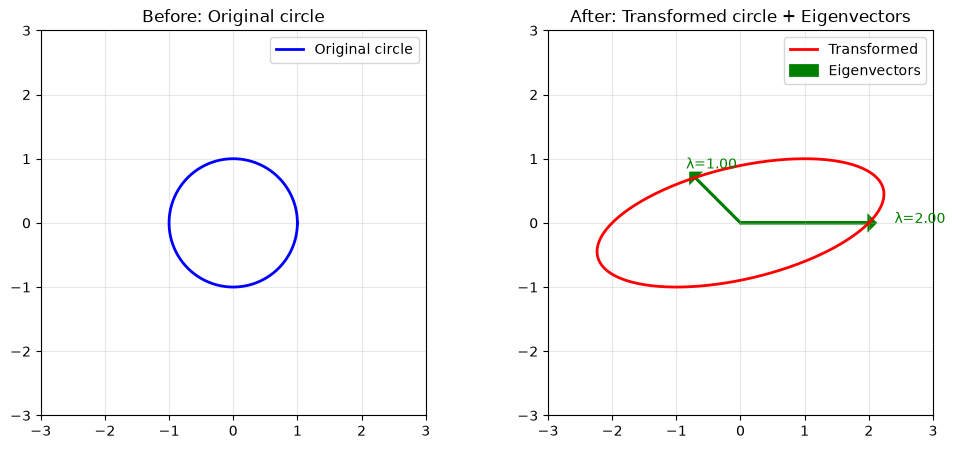

Eigenvalues: [2. 1.]
Eigenvectors:
 [[ 1.         -0.70710678]
 [ 0.          0.70710678]]


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Create a circle of points
theta = np.linspace(0, 2*np.pi, 100)
original_points = np.array([np.cos(theta), np.sin(theta)])

# Define a matrix that does something interesting
M = np.array([[2, 1], 
              [0, 1]])

# Apply the matrix to all points
transformed_points = M @ original_points

# Compute eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(M)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original
ax1.plot(original_points[0], original_points[1], 'b-', linewidth=2, label='Original circle')
ax1.set_xlim(-3, 3)
ax1.set_ylim(-3, 3)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.set_title('Before: Original circle')
ax1.legend()

# Transformed
ax2.plot(transformed_points[0], transformed_points[1], 'r-', linewidth=2, label='Transformed')

# Plot eigenvectors as arrows (scaled by eigenvalues)
for i in range(2):
    eigvec = eigenvectors[:, i]
    eigenval = eigenvalues[i]
    ax2.arrow(0, 0, eigvec[0]*eigenval, eigvec[1]*eigenval, 
              head_width=0.2, head_length=0.1, fc='green', ec='green', linewidth=2)
    ax2.text(eigvec[0]*eigenval*1.2, eigvec[1]*eigenval*1.2, 
             f'λ={eigenval:.2f}', fontsize=10, color='green')

ax2.set_xlim(-3, 3)
ax2.set_ylim(-3, 3)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.set_title('After: Transformed circle + Eigenvectors')
ax2.legend(['Transformed', 'Eigenvectors'])

plt.show()

# Print eigenvalues and eigenvectors
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

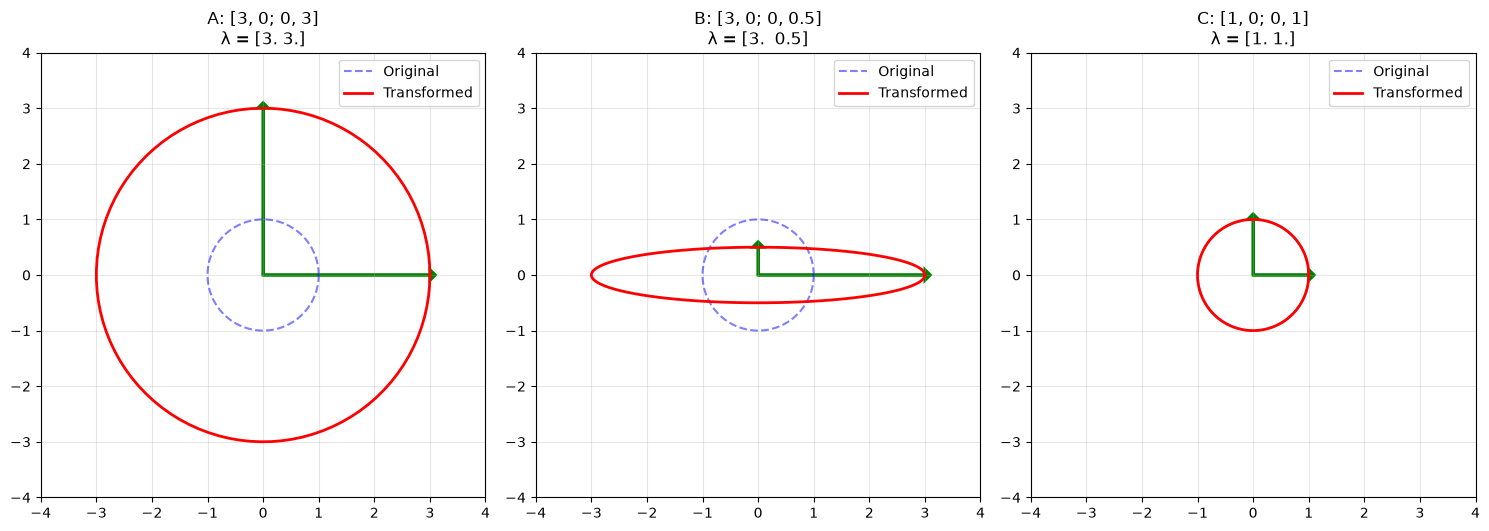

In [20]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, 2*np.pi, 100)
original_points = np.array([np.cos(theta), np.sin(theta)])

matrices = {
    'A: [3, 0; 0, 3]': np.array([[3, 0], [0, 3]]),
    'B: [3, 0; 0, 0.5]': np.array([[3, 0], [0, 0.5]]),
    'C: [1, 0; 0, 1]': np.array([[1, 0], [0, 1]])
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, M) in enumerate(matrices.items()):
    transformed = M @ original_points
    eigenvalues, eigenvectors = np.linalg.eig(M)
    
    ax = axes[idx]
    ax.plot(original_points[0], original_points[1], 'b--', alpha=0.5, label='Original')
    ax.plot(transformed[0], transformed[1], 'r-', linewidth=2, label='Transformed')
    
    # Plot eigenvectors
    for i in range(2):
        eigvec = eigenvectors[:, i]
        eigenval = eigenvalues[i]
        ax.arrow(0, 0, eigvec[0]*eigenval, eigvec[1]*eigenval,
                head_width=0.2, head_length=0.1, fc='green', ec='green', linewidth=2)
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{name}\nλ = {eigenvalues}')
    ax.legend()

plt.tight_layout()
plt.show()